# Lib


In [2]:
import json

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

from collections import Counter

import warnings

warnings.filterwarnings("ignore")

# Data


In [3]:
# Load Labels
df_target = pd.read_csv("../../data/github_social_network/musae_git_target.csv")
df_target.columns = df_target.columns.str.strip().str.lower().str.replace(" ", "_")

# Load Edges
df_edges = pd.read_csv("../../data/github_social_network/musae_git_edges.csv")
df_edges.columns = df_edges.columns.str.strip().str.lower().str.replace(" ", "_")

# Load Features
with open("../../data/github_social_network/musae_git_features.json", "r") as f:
    features_json = json.load(f)

In [4]:
print(f"Labels: {len(df_target)}")
print(f"Edges: {len(df_edges)}")
print(f"Features: {len(features_json)}")

Labels: 37700
Edges: 289003
Features: 37700


# Overview


In [5]:
print(f"Shape: {df_target.shape}")

print("\nColumns:")
print(df_target.columns.tolist())

df_target.head()

Shape: (37700, 3)

Columns:
['id', 'name', 'ml_target']


,id,name,ml_target
0,0,Eiryyy,0
1,1,shawflying,0
2,2,JpMCarrilho,1
3,3,SuhwanCha,0
4,4,sunilangadi2,1


In [6]:
print(f"Shape: {df_edges.shape}")

print("\nColumns:")
print(df_edges.columns.tolist())

df_edges.head()

Shape: (289003, 2)

Columns:
['id_1', 'id_2']


,id_1,id_2
0,0,23977
1,1,34526
2,1,2370
3,1,14683
4,1,29982


In [7]:
print(f"Number of nodes with features: {len(features_json)}")

sample_key = list(features_json.keys())[0]
print(f"\nSample node id: {sample_key}")
print(f"Feature indices: {features_json[sample_key][:10]}")

Number of nodes with features: 37700

Sample node id: 0
Feature indices: [1574, 3773, 3571, 2672, 2478, 2534, 3129, 3077, 1171, 2045]


# Graph


In [8]:
G = nx.from_pandas_edgelist(
    df_edges, source="id_1", target="id_2", create_using=nx.DiGraph()
)

In [9]:
print(G)

DiGraph with 37700 nodes and 289003 edges


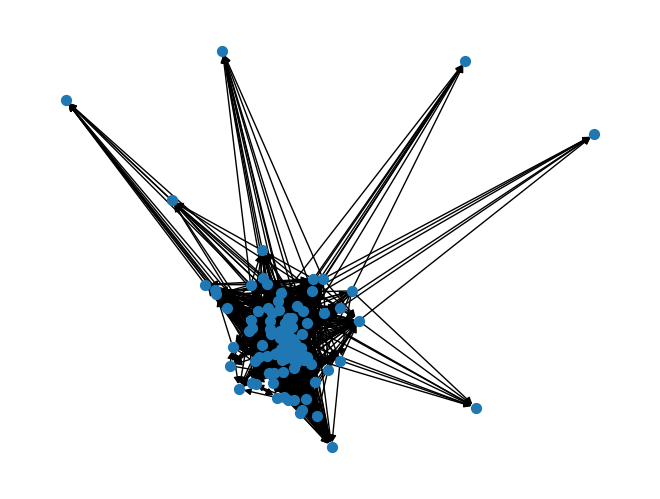

In [13]:
# Visualize top 100 nodes by degree
k = 100
top_nodes = sorted(G.nodes(), key=lambda n: G.degree(n), reverse=True)[:k]
H = G.subgraph(top_nodes)
nx.draw_spring(H, node_size=50, with_labels=False)
plt.show()

# Summary


In [ ]:
num_nodes = G.number_of_nodes()
num_edges = G.number_of_edges()
print(f"Number of users (nodes): {num_nodes}")
print(f"Number of follow relationships (edges): {num_edges}")

Number of users (nodes): 37700
Number of follow relationships (edges): 289003


In [ ]:
# Directed / Undirected
print(f"Graph type: {'Directed Graph' if G.is_directed() else 'Undirected Graph'}")

Graph type: Directed Graph


In [ ]:
# Density
density = nx.density(G)
print(f"Graph density: {density:.8f}")

Graph density: 0.00020334


In [ ]:
# Average degree
degrees = dict(G.degree())

avg_degree = np.mean(list(degrees.values()))

print(f"Average degree: {avg_degree:.2f}")

Average degree: 15.33


In [ ]:
print(f"Number of users (nodes): {num_nodes}")
print(f"Number of follow relationships (edges): {num_edges}")
print(f"Graph type: {'Directed Graph' if G.is_directed() else 'Undirected Graph'}")
print(f"Graph density: {density:.8f}")
print(f"Average degree: {avg_degree:.2f}")

# Data quality


## Mising values

In [ ]:
df_target.isnull().sum()

id           0
name         0
ml_target    0
dtype: int64

In [ ]:
df_edges.isnull().sum()

id_1    0
id_2    0
dtype: int64

## Dupliate edges

In [ ]:
duplicate_edges = df_edges.duplicated().sum()
print(f"Duplicate edges: {duplicate_edges}")

Duplicate edges: 0


## Self-loops

In [ ]:
self_loops = list(nx.selfloop_edges(G))
print(f"Number of self-loops: {len(self_loops)}")

Number of self-loops: 0


## Isolated Nodes

In [ ]:
isolated_nodes = list(nx.isolates(G))

print(f"Number of isolated nodes: {len(isolated_nodes)}")

Number of isolated nodes: 0


# Degree analysis

In [ ]:
# In-degree = followers
in_degree_dict = dict(G.in_degree())
# Out-degree = following
out_degree_dict = dict(G.out_degree())

## Top followers


In [ ]:
top_followers = pd.DataFrame(
    {"node_id": list(in_degree_dict.keys()), "followers": list(in_degree_dict.values())}
).sort_values(by="followers", ascending=False)

print("Top 10 Users by Followers")

top_followers.head(10)

Top 10 Users by Followers


,node_id,followers
28,31890,7470
35,35773,2401
52,36652,2285
165,18163,1858
82,19222,1499
357,36628,1477
120,35008,1472
234,3712,884
109,13638,858
116,30002,819


## Degree distribution


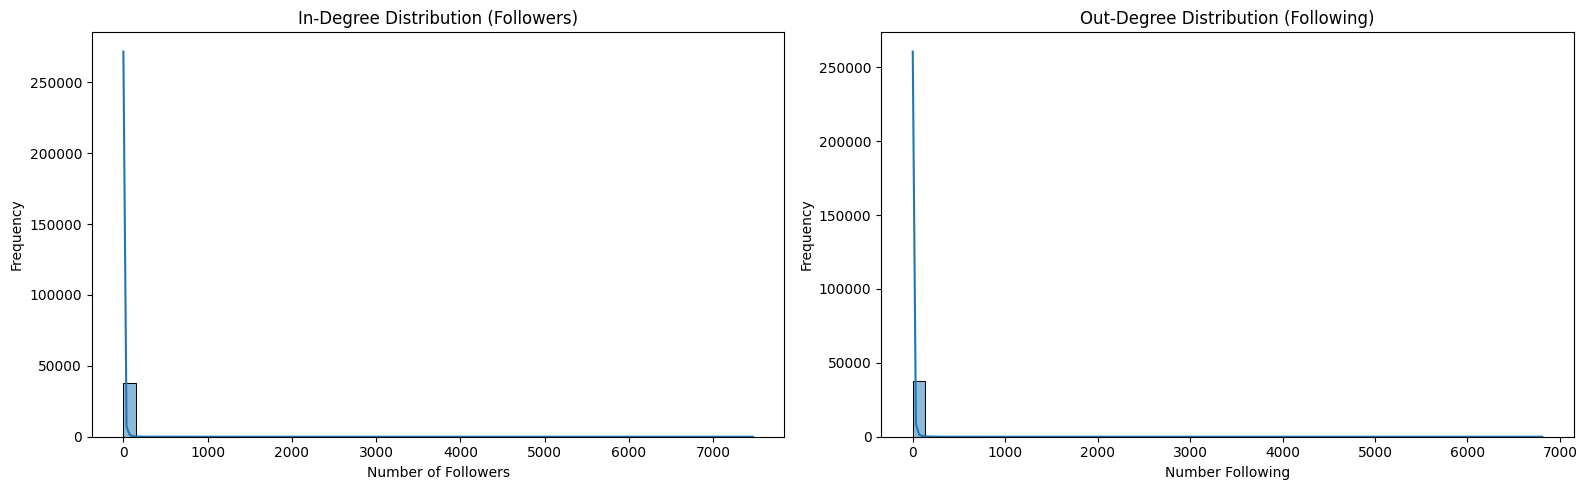

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# In-degree distribution
sns.histplot(list(in_degree_dict.values()), bins=50, kde=True, ax=axes[0])

axes[0].set_title("In-Degree Distribution (Followers)")
axes[0].set_xlabel("Number of Followers")
axes[0].set_ylabel("Frequency")

# Out-degree distribution
sns.histplot(list(out_degree_dict.values()), bins=50, kde=True, ax=axes[1])

axes[1].set_title("Out-Degree Distribution (Following)")
axes[1].set_xlabel("Number Following")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

# Log-Log degree distribution


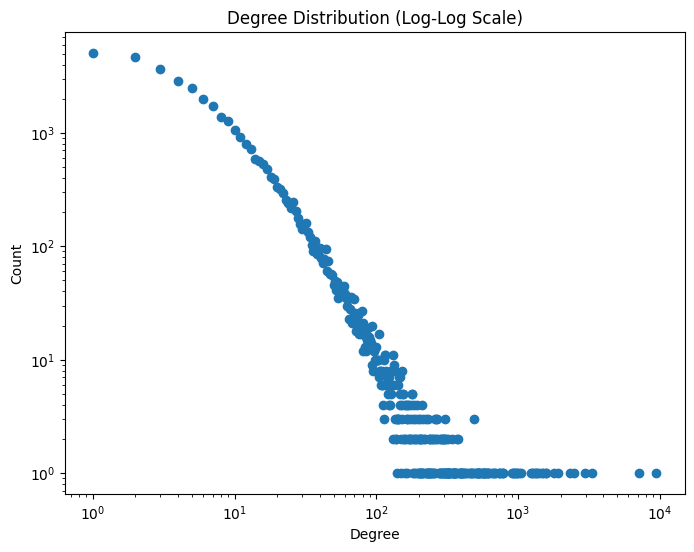

In [ ]:
degree_sequence = sorted([d for n, d in G.degree()], reverse=True)

degree_count = Counter(degree_sequence)

deg, cnt = zip(*degree_count.items())

plt.figure(figsize=(8, 6))

plt.scatter(deg, cnt)

plt.xscale("log")
plt.yscale("log")

plt.title("Degree Distribution (Log-Log Scale)")
plt.xlabel("Degree")
plt.ylabel("Count")

plt.show()

# Connected components


In [ ]:
# Weakly connected components
weak_components = list(nx.weakly_connected_components(G))
print(f"Weakly Connected Components: {len(weak_components)}")

largest_weak_cc = max(weak_components, key=len)
print(f"Largest Weakly Connected Component: {len(largest_weak_cc)} nodes")

Weakly Connected Components: 1
Largest Weakly Connected Component: 37700 nodes


In [ ]:
# Strongly connected components
strong_components = list(nx.strongly_connected_components(G))
print(f"Strongly Connected Components: {len(strong_components)}")

largest_strong_cc = max(strong_components, key=len)
print(f"Largest Strongly Connected Component: {len(largest_strong_cc)} nodes")

Strongly Connected Components: 37700
Largest Strongly Connected Component: 1 nodes


# Basic Network Statistics

In [ ]:
# Average clustering coefficient
avg_clustering = nx.average_clustering(G.to_undirected())
print(f"Average Clustering Coefficient: {avg_clustering:.4f}")

# Reciprocity
reciprocity = nx.reciprocity(G)
print(f"Reciprocity: {reciprocity:.4f}")

Average Clustering Coefficient: 0.1675
Reciprocity: 0.0000
